<a href="https://creativecommons.org">LaserIllumination</a> © 2025 by <a href="https://creativecommons.org">M. Cotelo, A. Lorca (Universidad Politécnica de Madrid)</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/sa.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# LaserIllumination

Authors:
- Manuel Cotelo Ferreiro (<manuel.cotelo@upm.es>) (Instituto de Fusión Nuclear Guillermo Velarde, Universidad Politécnica de Madrid)
- Alberto Lorca (<alberto.lorca@alumnos.upm.es>) (Universidad Politécnica de Madrid)

In [105]:
import os
import sys
import argparse
import string

In [106]:
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
#!pip install scipy

## Helper functions

In [107]:
def sph_to_cart(r, theta, phi):
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)
    return np.array([x, y, z])

## Chamber and target geometry parameters

In [108]:
# Radio del círculo INSCRITO en la ventana 40x40 cm
R_INSCRITO = 0.20    # metros (20 cm)
R_TARGET = 0.001     # metros (1 mm)
R_CAMARA = 5.0       # metros (ventana -> blanco)
VENTANA_SIZE = 0.80


## Define ports in NIF

In [109]:
def get_ports_dataframe():
    """
    Genera el DataFrame con la configuración oficial de los 48 puertos (NIF)
    siguiendo estrictamente el esquema del usuario.
    """
    def create_ports(theta, num, long_ref, root, color, energy, wavelength):
        list_long = long_ref + np.linspace(0., 2.*np.pi, num, endpoint=False)
        return [{
            'name': f'{root}J{i+1}',
            'LAT': theta,
            'LONG': long,
            'color': color,
            'energia': energy,
            'longonda': wavelength,
        } for i, long in enumerate(list_long)]

    ports = []
    # Hemisferio Norte
    ports += create_ports(np.deg2rad(23.5), 4, 0.,           'NP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.deg2rad(30.0), 4, np.pi/4.,     'NP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.deg2rad(44.5), 8, np.pi/16.,    'NP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.deg2rad(50.0), 8, 3*np.pi/16.,  'NP4', 'purple', 1.0, 351e-6)
    
    # Hemisferio Sur
    ports += create_ports(np.pi - np.deg2rad(23.5), 4, 0.,   'SP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(30.0), 4, np.pi/4., 'SP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(44.5), 8, np.pi/16., 'SP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(50.0), 8, 3*np.pi/16., 'SP4', 'purple', 1.0, 351e-6)

    ports_df = pd.DataFrame(ports)
    return ports_df

# Creamos el objeto para que lo usen las funciones posteriores
ports = get_ports_dataframe()

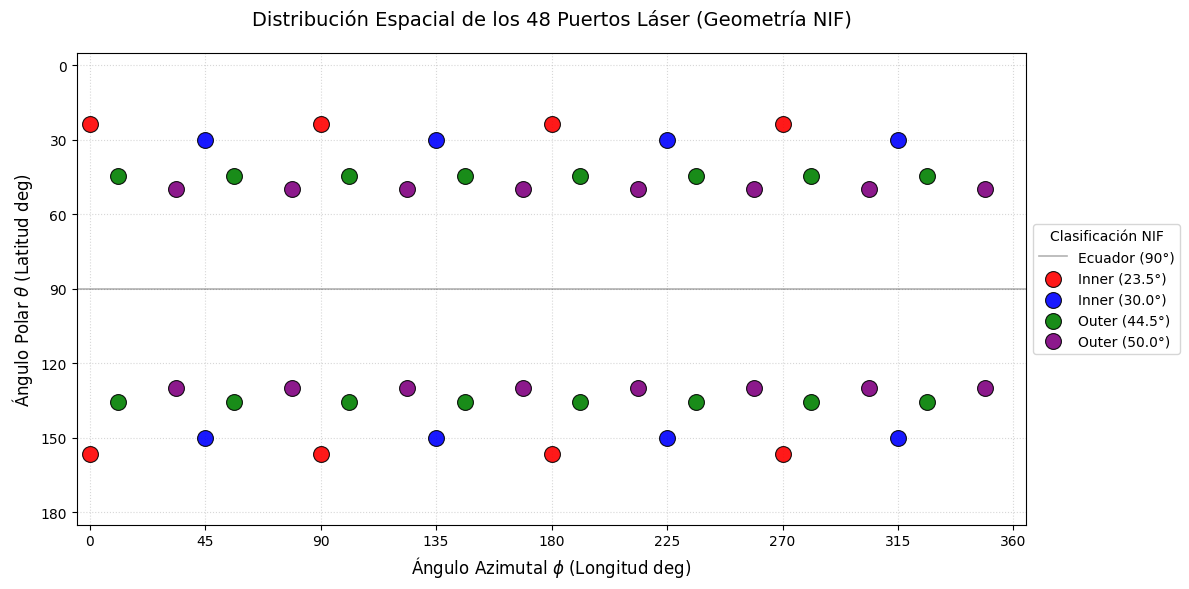

In [110]:

# --- Configuración de la figura definitiva ---
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# 1. Líneas de referencia
# Ecuador en el centro exacto
ax.axhline(90, color='black', linestyle='-', linewidth=1.2, alpha=0.3, label='Ecuador (90°)')

# 2. Diccionario de etiquetas
etiquetas = {
    'red': 'Inner (23.5°)',
    'blue': 'Inner (30.0°)',
    'green': 'Outer (44.5°)',
    'purple': 'Outer (50.0°)'
}

# 3. Dibujar los puertos
# Iteramos para asegurar el orden de la leyenda
for color_haz in ['red', 'blue', 'green', 'purple']:
    subdf = ports[ports['color'] == color_haz]
    if not subdf.empty:
        ax.scatter(
            np.rad2deg(subdf['LONG']), 
            np.rad2deg(subdf['LAT']), 
            s=130, 
            c=color_haz, 
            marker='o', 
            label=etiquetas.get(color_haz), 
            edgecolors='black', 
            linewidths=0.8,
            zorder=10,
            alpha=0.9
        )

# 4. Configuración de Ejes (LA CLAVE DEL CAMBIO)
ax.set_title('Distribución Espacial de los 48 Puertos Láser (Geometría NIF)', fontsize=14, pad=20)
ax.set_xlabel('Ángulo Azimutal $\phi$ (Longitud deg)', fontsize=12)
ax.set_ylabel('Ángulo Polar $\\theta$ (Latitud deg)', fontsize=12)

# Definimos los límites de forma natural
ax.set_xlim(-5, 365)
ax.set_ylim(-5, 185) 

# Invertimos el eje Y: ahora el 0 estará ARRIBA y el 180 ABAJO
# Esto garantiza que 23.5° esté más cerca del borde superior que 50°
ax.invert_yaxis()

# Ticks
ax.set_xticks(np.arange(0, 361, 45))
ax.set_yticks(np.arange(0, 181, 30))

# Estética
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Clasificación NIF", frameon=True)

plt.tight_layout()
plt.show()

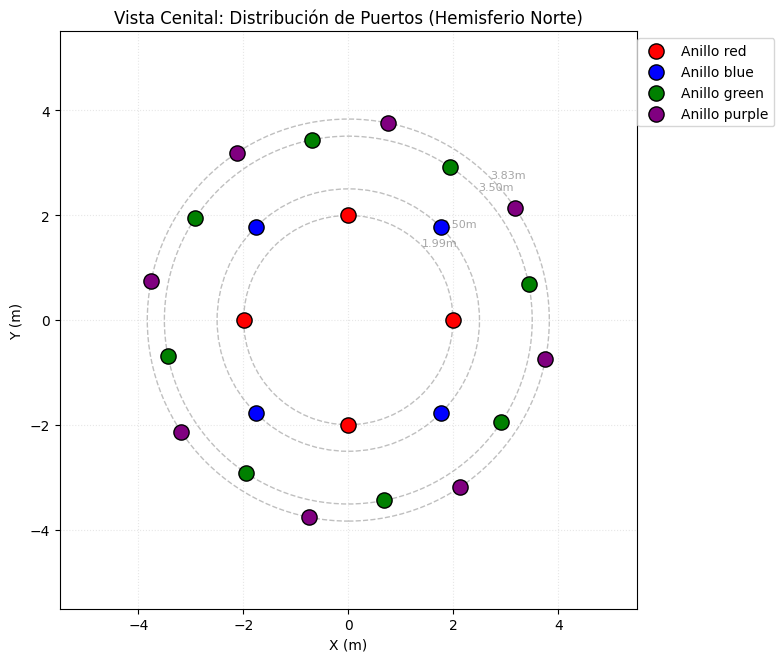

In [111]:
# --- 1. Preparación de datos ---
# Filtramos puertos del Hemisferio Norte (LAT < 90 grados o < pi/2)
# Nota: En tu esquema, el norte va de 0 a pi/2
ports_north = ports[ports['LAT'] < np.pi/2].copy()

# Calculamos coordenadas cartesianas para la proyección
# r = R * sin(theta) es el radio proyectado en el plano XY
R_CAMARA = 5.0
theta = ports_north['LAT'].values
phi = ports_north['LONG'].values

x_coords = R_CAMARA * np.sin(theta) * np.cos(phi)
y_coords = R_CAMARA * np.sin(theta) * np.sin(phi)

# --- 2. Configuración de la figura ---
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Vista Cenital: Distribución de Puertos (Hemisferio Norte)')
ax.set_aspect('equal', 'box')

# --- 3. Dibujar los Puertos ---
# Usamos el índice de ports_north para mapear correctamente x_coords e y_coords
for ci in ports_north['color'].unique():
    # Obtenemos los índices locales de este color
    mask = (ports_north['color'] == ci).values
    
    ax.scatter(
        x_coords[mask], 
        y_coords[mask], 
        s=120, 
        c=ci, 
        edgecolors='black',
        label=f'Anillo {ci}', 
        zorder=10
    )

# --- 4. Dibujar los anillos de referencia (Círculos concéntricos) ---
# Calculamos la distancia al origen en el plano XY para cada puerto
distancias_proyectadas = np.sqrt(x_coords**2 + y_coords**2)
radios_unicos = np.unique(np.round(distancias_proyectadas, 4))

for r in radios_unicos:
    circle = plt.Circle((0., 0.), r, color='gray', fill=False, linestyle='--', alpha=0.5, zorder=1)
    ax.add_artist(circle)
    # Etiqueta opcional del radio del anillo
    ax.text(r * 0.707, r * 0.707, f'{r:.2f}m', color='gray', fontsize=8, alpha=0.7)

# --- 5. Estética final ---
limit = R_CAMARA + 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.grid(True, linestyle=':', alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

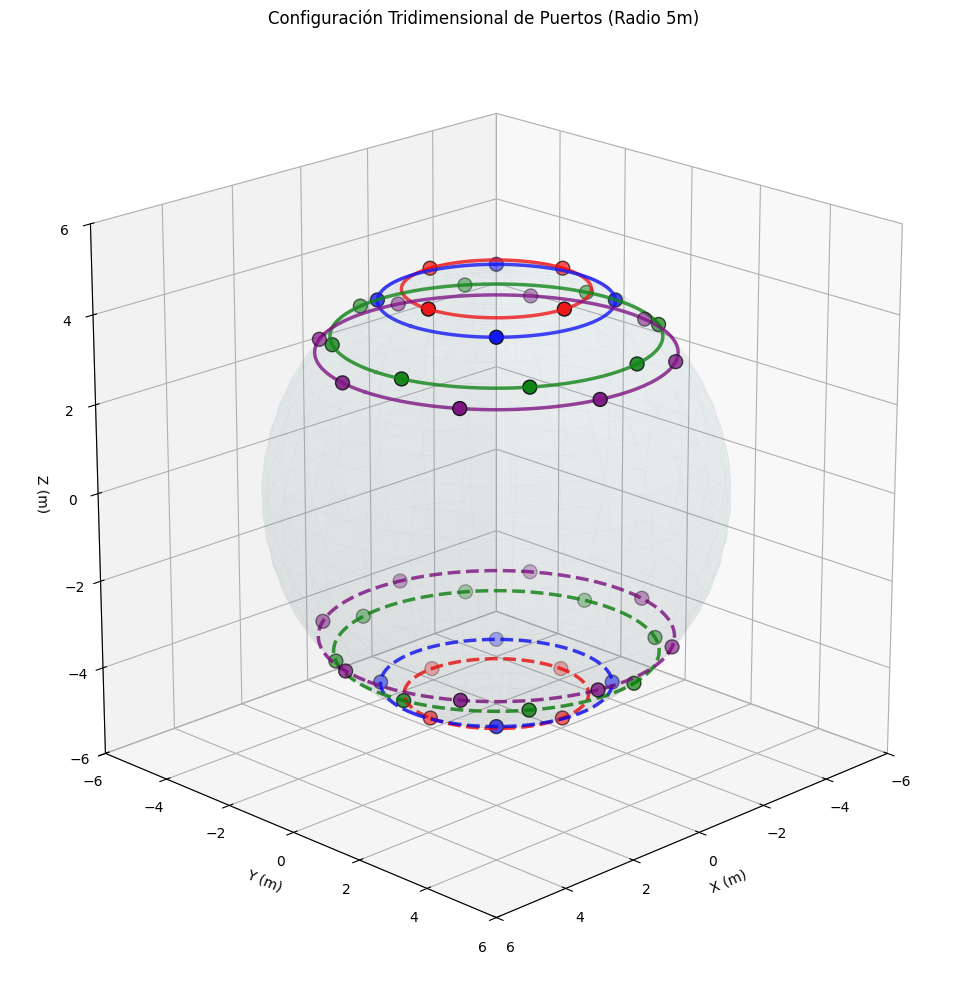

In [112]:

# --- Parámetros y Configuración ---
fig = plt.subplots(figsize=(10, 10), subplot_kw={'projection': '3d'})[0]
ax = fig.gca()
ax.set_box_aspect([1, 1, 1])

R = 5  # Radio real de la cámara
limit = R + 1
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit, limit])

# --- Dibujar los Puertos ---
for ci in ports['color'].unique():
    subdf = ports[ports['color'] == ci]
    
    # Conversión esférica → cartesiana (LAT es el ángulo polar theta)
    theta = subdf['LAT'].values
    phi = subdf['LONG'].values
    
    x = R * np.sin(theta) * np.cos(phi)
    y = R * np.sin(theta) * np.sin(phi)
    z = R * np.cos(theta)
    
    ax.scatter(x, y, z, s=100, c=ci, marker='o', 
               edgecolors='black', label=f'Puertos {ci}', zorder=10)

# --- Dibujar Anillos (Trayectorias circulares) ---
phi_line = np.linspace(0, 2 * np.pi, 200)

for ci in ports['color'].unique():
    # Separamos por hemisferios basándonos en si LAT < pi/2 (Norte) o > pi/2 (Sur)
    for h_type, mask in [
        ("Norte", ports['LAT'] < np.pi/2),
        ("Sur",   ports['LAT'] > np.pi/2)
    ]:
        subdf = ports[(ports['color'] == ci) & mask]
        
        if not subdf.empty:
            # Ángulo polar promedio del anillo
            theta0 = np.mean(subdf['LAT'].values)

            # Ecuaciones paramétricas del círculo en 3D
            x_circ = R * np.sin(theta0) * np.cos(phi_line)
            y_circ = R * np.sin(theta0) * np.sin(phi_line)
            z_circ = R * np.cos(theta0) * np.ones_like(phi_line)

            ax.plot(x_circ, y_circ, z_circ, color=ci, linewidth=2.5,
                    linestyle="-" if h_type == "Norte" else "--", 
                    alpha=0.8, zorder=5)

# --- Esfera de la Cámara (Transparente) ---
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 30)
x_s = R * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_s = R * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_s = R * np.outer(np.ones_like(u_sphere), np.cos(v_sphere))

ax.plot_surface(x_s, y_s, z_s, alpha=0.07, color='lightblue', edgecolor='gray', linewidth=0.1)

# --- Ejes y Etiquetas ---
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('Configuración Tridimensional de Puertos (Radio 5m)')

# Mejorar la perspectiva inicial
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## Define and create beams based on NIF

In [113]:
def beam():
    # =====================================================
    # 1. Definición de puertos (Estructura base)
    # =====================================================
    def create_ports(theta, num, long_ref, root, color, energy, wavelength):
        list_long = long_ref + np.linspace(0., 2.*np.pi, num, endpoint=False)
        return [{
            'name': f'{root}J{i+1}',
            'LAT': theta,
            'LONG': long,
            'color': color,
            'energia': energy,
            'longonda': wavelength,
        } for i, long in enumerate(list_long)]

    ports = []
    # Hemisferio Norte
    ports += create_ports(np.deg2rad(23.5), 4, 0.,           'NP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.deg2rad(30.0), 4, np.pi/4.,     'NP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.deg2rad(44.5), 8, np.pi/16.,    'NP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.deg2rad(50.0), 8, 3*np.pi/16.,  'NP4', 'purple', 1.0, 351e-6)
    # Hemisferio Sur
    ports += create_ports(np.pi - np.deg2rad(23.5), 4, 0.,   'SP1', 'red',    1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(30.0), 4, np.pi/4., 'SP2', 'blue',   1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(44.5), 8, np.pi/16., 'SP3', 'green',  1.0, 351e-6)
    ports += create_ports(np.pi - np.deg2rad(50.0), 8, 3*np.pi/16., 'SP4', 'purple', 1.0, 351e-6)

    ports_df = pd.DataFrame(ports)

    # =====================================================
    # 2. Geometría de Ventanas y Subventanas
    # =====================================================
    def compute_geom(row):
        R = 5.0  # Radio de la cámara
        theta = row['LAT']
        phi = row['LONG']
        
        # Vector normal unitario (radial desde el origen)
        normal_u = np.array([
            np.sin(theta) * np.cos(phi),
            np.sin(theta) * np.sin(phi),
            np.cos(theta)
        ])
        
        # Posición del centro del puerto en la superficie de la cámara
        port_center = normal_u * R

        # Ejes tangenciales para definir el plano de la ventana
        # t1: Dirección azimutal (Este-Oeste)
        t1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
        if np.linalg.norm(t1) < 1e-6: t1 = np.array([1, 0, 0])
        t1 /= np.linalg.norm(t1)
        
        # t2: Dirección polar (Norte-Sur)
        t2 = np.cross(normal_u, t1)
        t2 /= np.linalg.norm(t2)

        # Dimensiones: Ventana 80x80cm -> 4 Subventanas de 40x40cm
        ports_size = 0.80
        l_sub = ports_size / 2.0  # 0.40 m

        # Centros de las 4 subventanas en el plano tangente
        # Desplazamos l_sub/4 desde el centro del puerto para situar los centros de las subventanas
        d = l_sub / 2.0 
        offsets = [
            (+d, +d), (-d, +d),
            (+d, -d), (-d, -d)
        ]

        sub_centers = [port_center + dx * t1 + dy * t2 for dx, dy in offsets]

        return pd.Series({
            'normal_u': normal_u,
            'port_center': port_center,
            't1': t1,
            't2': t2,
            'l_sub': l_sub,
            'sub_centers': sub_centers
        })

    # Concatenamos la geometría calculada al DataFrame
    geom_data = ports_df.apply(compute_geom, axis=1)
    ports_df = pd.concat([ports_df, geom_data], axis=1)

    # =====================================================
    # 3. Construcción de la lista final de haces (Beams)
    # =====================================================
    beam_list = []
    for _, row in ports_df.iterrows():
        for i, center in enumerate(row['sub_centers']):
            beam_list.append({
                'port': row['name'],
                'subwindow_index': i,
                'LAT': row['LAT'],
                'LONG': row['LONG'],
                'color': row['color'],
                'energy': row['energia'],
                'wavelength': row['longonda'],
                'center': center,          # Centro de la subventana (posicion inicial haz)
                'normal': row['normal_u'], # Eje de propagación (radial)
                't1': row['t1'],           # Orientación local
                't2': row['t2'],           # Orientación local
                'radius_base': row['l_sub'] / 2.0, # Radio círculo inscrito (20cm)
                'focus': None              # <--- A RELLENAR MÁS ADELANTE
            })

    return beam_list

## Focal distance

### Focal distance calculation paramethers

In [114]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calcula la distancia focal con un desfase (defocus).
    Un defocus positivo aleja el foco del blanco, ensanchando el haz.
    """
    # R_TARGET real es el tamaño deseado del haz en el origen.
    # Si sumamos defocus_mm, el haz será más ancho al pasar por la esfera.
    efective_target = R_TARGET + (defocus_mm / 1000.0) 
    
    f_window = (R_INSCRITO * R_CAMARA) / (R_INSCRITO - efective_target)
    return f_window

def compute_focus(sub_window_center, f_window):
    # Vector unitario desde el centro de la subventana hacia el centro de la cámara
    normal_local = sub_window_center / np.linalg.norm(sub_window_center)
    
    # El foco se aleja siguiendo la línea del eje óptico
    focus_pos = sub_window_center - (normal_local * f_window)
    return focus_pos

def assign_real_focus(beam_row):
    # Usamos un defocus de 2.0mm para que el haz "abrace" el blanco
    f_dist = compute_focal_distance(defocus_mm=0.25) 
    return compute_focus(beam_row["center"], f_dist)


In [115]:

# =====================================================
# Bucle de asignación para la lista beam_list
# =====================================================

# 1. Primero ejecutamos la función beam() de la Caja 1 para obtener la lista
beam_list = beam()

# 2. Recorremos la lista y actualizamos el campo 'focus' de cada haz
for b in beam_list:
    b['focus'] = assign_real_focus(b)


## Data frame of beams in geometry

In [116]:
df_beams = pd.DataFrame(beam_list)

# 2. Aseguramos que existan l1 y l2 (dimensiones de la subventana)
df_beams['l1'] = 0.40
df_beams['l2'] = 0.40

# 3. Función para desglosar los vectores [x, y, z] en columnas x, y, z
def expandir_columna_vectorial(df, columna):
    # Creamos un DF temporal con las 3 coordenadas
    temp = pd.DataFrame(df[columna].tolist(), index=df.index)
    temp.columns = [f'{columna}_x', f'{columna}_y', f'{columna}_z']
    return temp

# 4. Creamos las tablas expandidas
df_centers = expandir_columna_vectorial(df_beams, 'center')
df_t1      = expandir_columna_vectorial(df_beams, 't1')
df_t2      = expandir_columna_vectorial(df_beams, 't2')
df_normal  = expandir_columna_vectorial(df_beams, 'normal')
df_focus   = expandir_columna_vectorial(df_beams, 'focus')

# 5. Montamos la tabla final seleccionando y uniendo
columnas_datos = ['port', 'subwindow_index', 'LAT', 'LONG', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_beams_final = pd.concat([
    df_beams[columnas_datos],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Renombrado estético
df_beams_final = df_beams_final.rename(columns={'subwindow_index': 'subwindow'})

# 7. Resultado
df_beams_final.head(10)

,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,NP1J1,0,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.008478,-0.000937,-0.021847
1,NP1J1,1,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,1.810333,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.008478,0.000937,-0.021847
2,NP1J1,2,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.010196,-0.000937,-0.021100
3,NP1J1,3,0.410152,0.000000,red,1.0,0.000351,0.4,0.4,2.177157,...,0.0,-9.170601e-01,-0.000000e+00,0.398749,3.987491e-01,0.000000e+00,0.91706,-0.010196,0.000937,-0.021100
4,NP1J2,0,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,-0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,0.000937,-0.008478,-0.021847
5,NP1J2,1,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,-0.000937,-0.008478,-0.021847
6,NP1J2,2,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,-0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,0.000937,-0.010196,-0.021100
7,NP1J2,3,0.410152,1.570796,red,1.0,0.000351,0.4,0.4,0.200000,...,0.0,-5.615373e-17,-9.170601e-01,0.398749,2.441634e-17,3.987491e-01,0.91706,-0.000937,-0.010196,-0.021100
8,NP1J3,0,0.410152,3.141593,red,1.0,0.000351,0.4,0.4,-1.810333,...,0.0,9.170601e-01,-1.123075e-16,0.398749,-3.987491e-01,4.883268e-17,0.91706,0.008478,0.000937,-0.021847
9,NP1J3,1,0.410152,3.141593,red,1.0,0.000351,0.4,0.4,-1.810333,...,0.0,9.170601e-01,-1.123075e-16,0.398749,-3.987491e-01,4.883268e-17,0.91706,0.008478,-0.000937,-0.021847


### Create 3D disposition of beams in NIF chamber

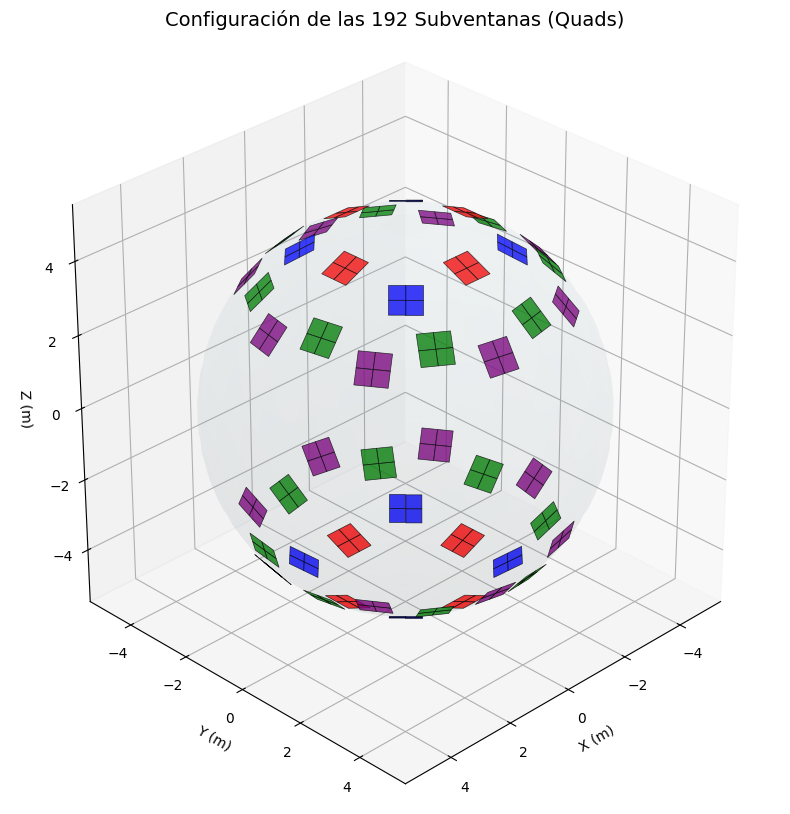

In [117]:

# --- Parámetros ---
R = 5.0

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# --- 1. Dibujar esfera de la cámara ---
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 30)
x_s = R * np.outer(np.cos(u), np.sin(v))
y_s = R * np.outer(np.sin(u), np.sin(v))
z_s = R * np.outer(np.ones_like(u), np.cos(v))
ax.plot_surface(x_s, y_s, z_s, color='lightblue', alpha=0.05, linewidth=0)

# --- 2. Colores por anillo (Mantenemos tus definidos) ---
ring_colors = {
    "NP1": "red", "SP1": "red",
    "NP2": "blue", "SP2": "blue",
    "NP3": "green", "SP3": "green",
    "NP4": "purple", "SP4": "purple",
}

# --- 3. Recorrer puertos y dibujar quads (4 subventanas por puerto) ---
# Usamos el DataFrame 'ports' que definimos con LAT y LONG
for idx, row in ports.iterrows():
    port_name = row["name"]
    ring_id = port_name[:3]
    color = ring_colors.get(ring_id, "orange")

    # Coordenadas esféricas directas (LAT = theta, LONG = phi)
    theta = row["LAT"]
    phi = row["LONG"]

    # Normal radial unitaria
    normal = np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])

    # Vectores tangenciales locales
    # t1: dirección azimutal
    t1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
    if np.linalg.norm(t1) < 1e-6: t1 = np.array([1, 0, 0])
    t1 /= np.linalg.norm(t1)
    
    # t2: dirección polar
    t2 = np.cross(normal, t1)
    t2 /= np.linalg.norm(t2)

    # Dimensiones (cada subventana es de 40x40cm = 0.4m)
    lx_sub = 0.4 
    ly_sub = 0.4
    
    # Centro del puerto en la superficie
    port_center = normal * R

    # Offsets para situar el CENTRO de cada una de las 4 subventanas
    # El puerto total es de 0.8, así que los centros están a +- 0.2
    d = 0.2 
    offsets = [(+d, +d), (-d, +d), (+d, -d), (-d, -d)]

    for dx, dy in offsets:
        sub_center = port_center + dx * t1 + dy * t2

        # Vértices de la subventana (0.4m de lado -> +-0.2 desde su sub_center)
        h = 0.2
        p1 = sub_center + h * t1 + h * t2
        p2 = sub_center - h * t1 + h * t2
        p3 = sub_center - h * t1 - h * t2
        p4 = sub_center + h * t1 - h * t2

        # Crear el polígono 3D
        verts = [p1, p2, p3, p4]
        poly = Poly3DCollection([verts], alpha=0.8, facecolor=color, edgecolor='black', linewidths=0.5)
        ax.add_collection3d(poly)

# --- 4. Ajustes finales de visualización ---
limit = R + 0.5
ax.set_xlim([-limit, limit])
ax.set_ylim([-limit, limit])
ax.set_zlim([-limit, limit])

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Configuración de las 192 Subventanas (Quads)", fontsize=14)

ax.set_box_aspect([1,1,1])
ax.view_init(elev=30, azim=45) # Perspectiva inclinada para ver ambos hemisferios

plt.show()

## Create 3D simulation of beams modeling them as if they were a cone, to see focal distance

## 1 window simulation to see focal distance

In [118]:

# --- Selección del PRIMER BEAM de la lista final ---
# Usamos el DataFrame df_final que creamos anteriormente
row = df_beams_final.iloc[0]  # Primer haz: NP1J1, subwindow 0

# --- Parámetros de la cápsula y cámara ---
R_TARGET = 0.001   # 1 mm
R_CAMARA = 5.0
R_INSCRITO = 0.20  # Radio de la base del cono (20 cm)

# --- Inicializar Plotter ---
plotter = pv.Plotter()
plotter.set_background("white")

# 1. Dibujar el Blanco (Cápsula de 1 mm) - Color Amarillo
target = pv.Sphere(radius=R_TARGET, center=(0.0, 0.0, 0.0), theta_resolution=100, phi_resolution=100)
plotter.add_mesh(target, color="yellow", opacity=1.0, label="Cápsula (1mm)")

# 2. Esfera de la cámara (Transparente para contexto)
chamber = pv.Sphere(radius=R_CAMARA, theta_resolution=60, phi_resolution=60)
plotter.add_mesh(chamber, color="lightblue", opacity=0.1)

# 3. Datos Geométricos del Haz desde el DataFrame
# Reconstruimos los vectores a partir de las columnas x, y, z
sub_window_center = np.array([row['center_x'], row['center_y'], row['center_z']])
focus_point = np.array([row['focus_x'], row['focus_y'], row['focus_z']])
t1 = np.array([row['t1_x'], row['t1_y'], row['t1_z']])
t2 = np.array([row['t2_x'], row['t2_y'], row['t2_z']])
color = row['color']
lx = row['l1'] # 0.4 m

# --- Visualización de la Base ---
# Cuadrado de la ventana (40x40 cm)
half_l = lx / 2
p1 = sub_window_center + half_l * t1 + half_l * t2
p2 = sub_window_center - half_l * t1 + half_l * t2
p3 = sub_window_center - half_l * t1 - half_l * t2
p4 = sub_window_center + half_l * t1 - half_l * t2

quad = pv.PolyData([p1, p2, p3, p4], [[4, 0, 1, 2, 3]])
plotter.add_mesh(quad, color="black", style="wireframe", line_width=2)

# Círculo inscrito (Base del haz)
circ_res = 100
phi = np.linspace(0, 2*np.pi, circ_res)
circ_pts = sub_window_center + (R_INSCRITO * np.cos(phi))[:, None] * t1 + \
                               (R_INSCRITO * np.sin(phi))[:, None] * t2
circle = pv.MultipleLines(circ_pts)
plotter.add_mesh(circle, color=color, line_width=4, label="Base Circular (20cm)")

# --- MODELADO DEL CONO (Foco Individual) ---
# Vector de BASE a PICO
direction_vector = focus_point - sub_window_center
height = np.linalg.norm(direction_vector)
dir_u = direction_vector / height

# El centro del objeto cono en PyVista es el punto medio del segmento
cone_center = sub_window_center + (dir_u * (height / 2.0))

cone = pv.Cone(
    center=cone_center,
    direction=dir_u,
    height=height,
    radius=R_INSCRITO,
    resolution=100,
    capping=True
)
plotter.add_mesh(cone, color=color, opacity=0.3, label=f"Haz {row['port']} Sub {row['subwindow']}")

# --- Ajustes de cámara y ejes ---
plotter.add_legend()
plotter.add_axes()

# Enfocar la cámara al centro para ver el impacto en la cápsula
plotter.camera.position = (0.05, 0.05, 0.05) # Posición muy cercana
plotter.camera.focal_point = (0, 0, 0)
plotter.show()

Widget(value='<iframe src="http://localhost:57567/index.html?ui=P_0x1d482a7ab90_19&reconnect=auto" class="pyvi…

## All beams simulation

In [119]:
# --- Inicializar plotter ---
plotter = pv.Plotter()
plotter.set_background("white")

# 1. Esfera de la cámara (muy transparente para ver el interior)
chamber = pv.Sphere(radius=R_CAMARA, theta_resolution=60, phi_resolution=60)
plotter.add_mesh(chamber, color="lightblue", opacity=0.2)

# 2. Blanco en el centro (Cápsula de 1 mm)
target = pv.Sphere(radius=R_TARGET, center=(0.0, 0.0, 0.0), theta_resolution=100, phi_resolution=100)
plotter.add_mesh(target, color="yellow", opacity=1.0)

# --- Recorrer el DataFrame definitivo (192 haces) ---
# Asumimos que df_final es el DataFrame que contiene center_x, focus_x, t1_x, t2_x, etc.
for idx, row in df_final.iterrows():
    color = row["color"]
    
    # Reconstrucción de vectores desde el DataFrame
    sub_window_center = np.array([row['center_x'], row['center_y'], row['center_z']])
    focus_point = np.array([row['focus_x'], row['focus_y'], row['focus_z']])
    t1 = np.array([row['t1_x'], row['t1_y'], row['t1_z']])
    t2 = np.array([row['t2_x'], row['t2_y'], row['t2_z']])
    
    # 3. Dibujar el marco de la ventana (Cuadrado de 40x40cm)
    half_l = row['l1'] / 2  # 0.2 m
    p1 = sub_window_center + half_l * t1 + half_l * t2
    p2 = sub_window_center - half_l * t1 + half_l * t2
    p3 = sub_window_center - half_l * t1 - half_l * t2
    p4 = sub_window_center + half_l * t1 - half_l * t2
    
    quad = pv.PolyData([p1, p2, p3, p4], [[4, 0, 1, 2, 3]])
    plotter.add_mesh(quad, color="black", style="wireframe", opacity=0.2, line_width=1)

    # 4. Modelado del Haz como CONO
    # Vector de BASE (ventana) a PICO (foco)
    direction_vector = focus_point - sub_window_center
    height = np.linalg.norm(direction_vector)
    dir_u = direction_vector / height
    
    # El centro geométrico del cono en PyVista es el punto medio del segmento ventana-foco
    cone_center = sub_window_center + (dir_u * (height / 2.0))
    
    # Crear el cono con el radio inscrito
    cone = pv.Cone(
        center=cone_center,
        direction=dir_u,
        height=height,
        radius=R_INSCRITO,
        resolution=50,
        capping=True
    )
    
    # Añadir a la escena con baja opacidad para apreciar la convergencia de los 192 rayos
    plotter.add_mesh(cone, color=color, opacity=0.3, show_edges=False)

# --- Configuración final de la vista ---
plotter.add_axes()
plotter.view_isometric()

# Nota: Si quieres verificar el impacto, puedes usar plotter.enable_zoom_style() 
# o fijar la cámara cerca del origen
print("Renderizando 192 haces enfocados a 1mm...")
plotter.show()

Renderizando 192 haces enfocados a 1mm...


Widget(value='<iframe src="http://localhost:57567/index.html?ui=P_0x1d4d22ebbd0_20&reconnect=auto" class="pyvi…

## Real simulation of beam impacts with square beams

In [120]:

# --- Inicializar plotter ---
plotter = pv.Plotter()
plotter.set_background("white")

# 1. Esfera de la cámara (Estructura de contención)
sphere = pv.Sphere(radius=R_CAMARA, theta_resolution=60, phi_resolution=60)
plotter.add_mesh(sphere, color="lightblue", opacity=0.05)

# 2. Blanco en el centro (Cápsula de combustible)
target = pv.Sphere(radius=R_TARGET, center=(0.0, 0.0, 0.0), theta_resolution=50, phi_resolution=50)
plotter.add_mesh(target, color="yellow", opacity=1.0)

# 3. Recorrer los 192 haces del DataFrame definitivo (df_final)
# Usamos el DataFrame para asegurar que cada subventana use su propio foco individual
for idx, row in df_final.iterrows():
    
    # Recuperar color y vectores del haz
    color = row["color"]
    sub_center = np.array([row['center_x'], row['center_y'], row['center_z']])
    focus_pt   = np.array([row['focus_x'], row['focus_y'], row['focus_z']])
    t1         = np.array([row['t1_x'], row['t1_y'], row['t1_z']])
    t2         = np.array([row['t2_x'], row['t2_y'], row['t2_z']])
    
    # Dimensiones de la subventana (40x40 cm)
    # l1 es el lado total (0.4m), usamos la mitad para los vértices
    h_l = row['l1'] / 2  

    # --- Calcular los 4 vértices de la base cuadrada en la ventana ---
    # Estos puntos están en la superficie de la cámara (R=5)
    p1 = sub_center + h_l * t1 + h_l * t2
    p2 = sub_center - h_l * t1 + h_l * t2
    p3 = sub_center - h_l * t1 - h_l * t2
    p4 = sub_center + h_l * t1 - h_l * t2

    # --- Crear la Pirámide ---
    # PyVista requiere los puntos de la base seguidos del vértice (pico)
    # Orden de puntos: [p1, p2, p3, p4, pico]
    pyramid = pv.Pyramid([p1, p2, p3, p4, focus_pt])
    
    # Añadir la pirámide al plotter
    # 'show_edges=True' permite ver la estructura del haz cuadrado
    plotter.add_mesh(
        pyramid, 
        color=color, 
        opacity=0.3, 
        show_edges=True, 
        edge_color=color,
        line_width=0.5
    )

# --- Configuración final de la vista ---
plotter.add_axes()
plotter.view_isometric()

# Zoom sugerido para ver el blanco
plotter.camera.zoom(1.2)

print("Visualizando 192 haces piramidales enfocados...")
plotter.show()

Visualizando 192 haces piramidales enfocados...


Widget(value='<iframe src="http://localhost:57567/index.html?ui=P_0x1d4dbea64d0_21&reconnect=auto" class="pyvi…